# ResearchIV 主入口

输入日期后，一键生成：
- 自动对齐到下一个交易日
- 近月/次近月平值 4 档合约的历史 IV
- 与标的 HV 的对比图

In [ ]:
from pathlib import Path
from IPython.display import Image, display

import pandas as pd

from Modules import build_term_atm_iv_hv_snapshot

pd.set_option("display.max_columns", 50)

In [ ]:
# 参数区
input_date = "2026-02-10"  # 非交易日会自动滚到下个交易日
etf_symbol = "S.CN.SZSE.159915"
lookback_days = 240
hv_window = 20
risk_free_rate = 0.015
dividend_yield = 0.0

In [ ]:
res = build_term_atm_iv_hv_snapshot(
    input_date=input_date,
    etf_symbol=etf_symbol,
    lookback_days=lookback_days,
    hv_window=hv_window,
    risk_free_rate=risk_free_rate,
    dividend_yield=dividend_yield,
)

print("input_date:", res["input_date"])
print("trade_date:", res["trade_date"])
print("plot_path:", res["plot_path"])

output_dir = Path(res["output_dir"])
plot_path = Path(res["plot_path"])

selected_contracts = (
    res["selected_contracts"]
    .sort_values(["term", "expiry", "strike"])
    .reset_index(drop=True)
)
selected_contracts

Retrying after 3 second... (Attempt 1/3)
Retrying after 3 second... (Attempt 2/3)


get_price(S.CN.SZSE.159915, 2026-03-02) failed, skip day: Error: 500 - Internal Server Error


Retrying after 3 second... (Attempt 1/3)
Retrying after 3 second... (Attempt 2/3)


get_price(S.CN.SZSE.159915, 2026-03-03) failed, skip day: Error: 500 - Internal Server Error


Retrying after 3 second... (Attempt 1/3)
Retrying after 3 second... (Attempt 2/3)


...

get_price(S.CN.SZSE.159915, 2026-03-11) failed, skip day: Error: 500 - Internal Server Error


Retrying after 3 second... (Attempt 1/3)
Retrying after 3 second... (Attempt 2/3)


get_price(S.CN.SZSE.159915, 2026-03-12) failed, skip day: Error: 500 - Internal Server Error


input_date: 2026-02-20
trade_date: 2026-02-24
plot_path: C:\Users\21927\trading\Backtest\ResearchIV\outputs\term_atm_iv_hv_20260224\term_atm_iv_hv.png


,term,trade_date,expiry,strike,call_symbol,put_symbol
0,near,2026-02-24,2026-02-25,3.1,O.CN.SZSE.159915.90006910,O.CN.SZSE.159915.90006919
1,near,2026-02-24,2026-02-25,3.2,O.CN.SZSE.159915.90006911,O.CN.SZSE.159915.90006920
2,near,2026-02-24,2026-02-25,3.3,O.CN.SZSE.159915.90006912,O.CN.SZSE.159915.90006921
3,near,2026-02-24,2026-02-25,3.4,O.CN.SZSE.159915.90006913,O.CN.SZSE.159915.90006922
4,next,2026-02-24,2026-03-25,3.1,O.CN.SZSE.159915.90006231,O.CN.SZSE.159915.90006232
5,next,2026-02-24,2026-03-25,3.2,O.CN.SZSE.159915.90006245,O.CN.SZSE.159915.90006247
6,next,2026-02-24,2026-03-25,3.3,O.CN.SZSE.159915.90006246,O.CN.SZSE.159915.90006248
7,next,2026-02-24,2026-03-25,3.4,O.CN.SZSE.159915.90006283,O.CN.SZSE.159915.90006284


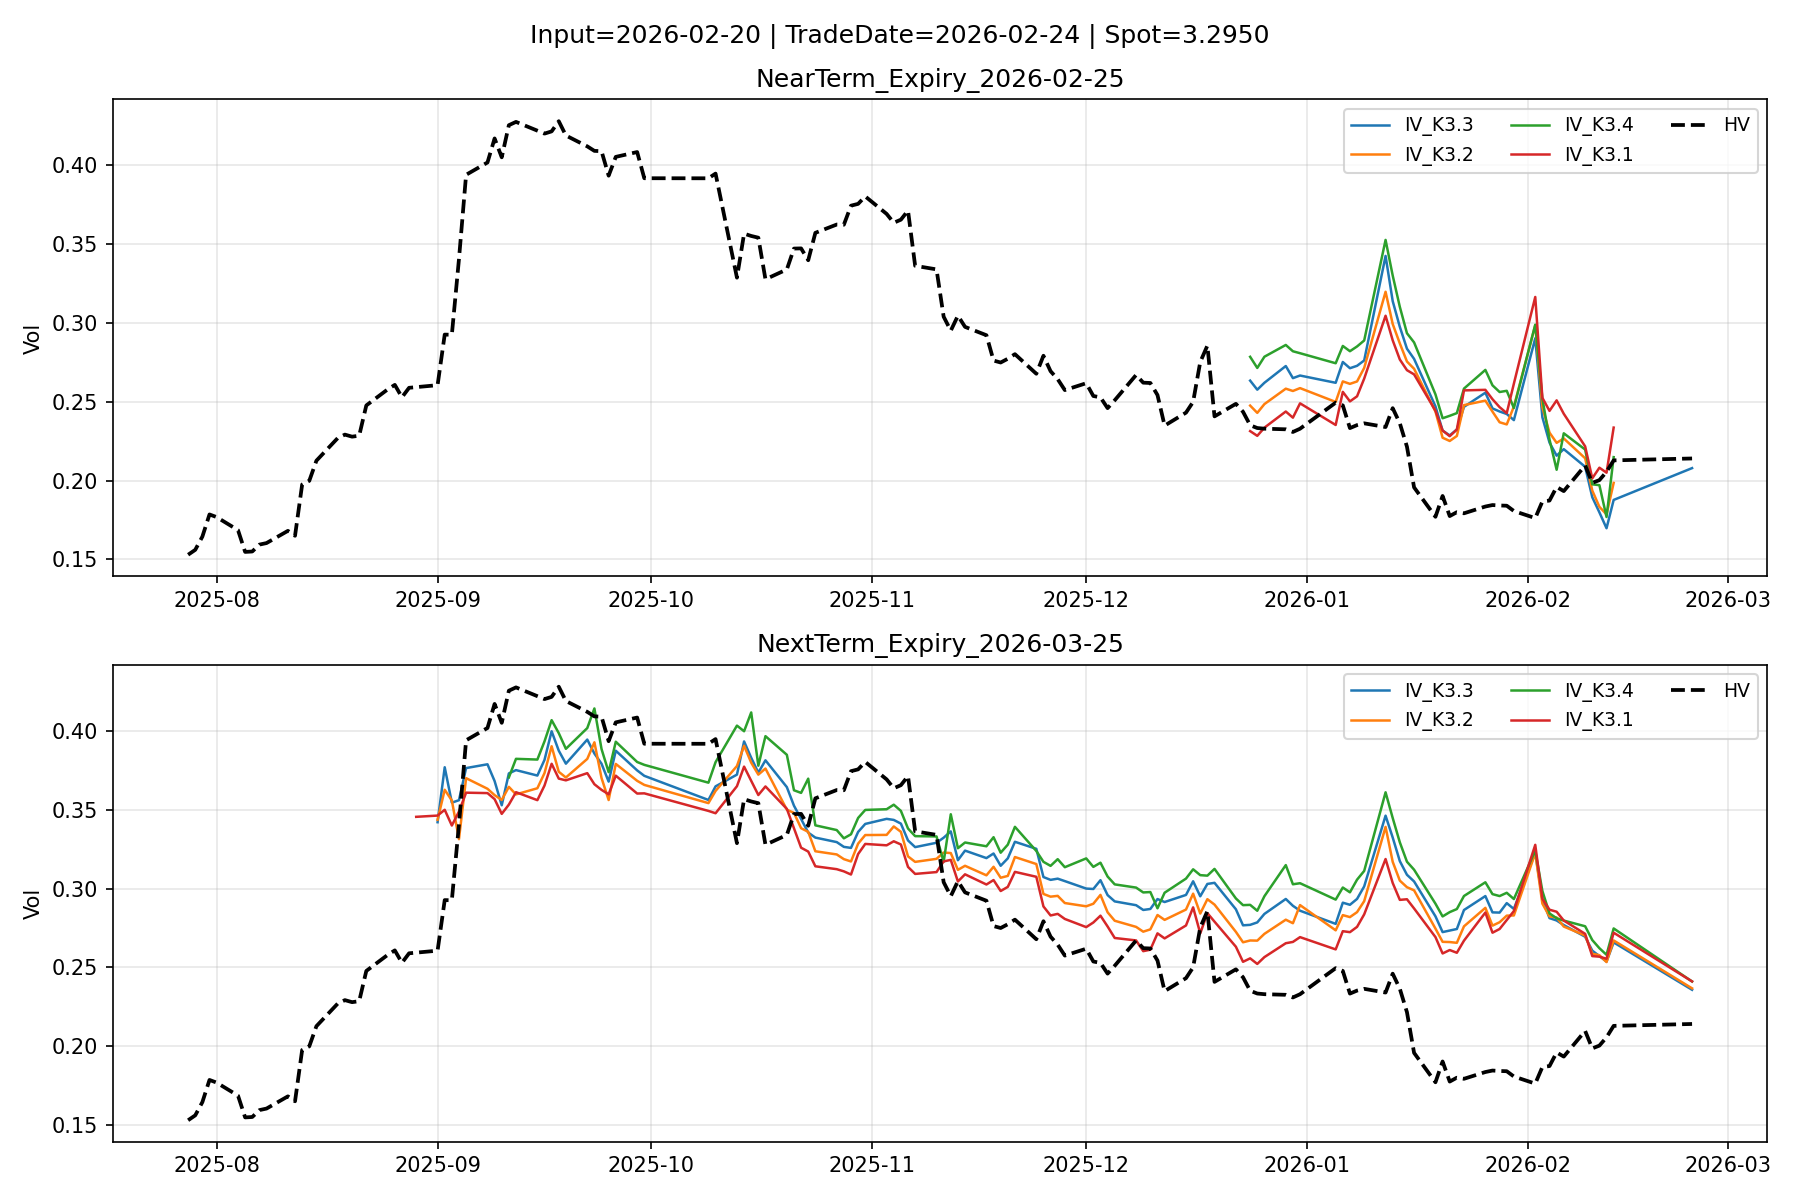

In [7]:
# 展示 IV/HV 图片
if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("未找到图片:", plot_path)

In [8]:
# 展示每个期限的明细（每档执行价一列 IV）
csv_list = sorted(output_dir.glob("*Term_Expiry_*.csv"))
if not csv_list:
    print("未找到期限明细 CSV")
else:
    for csv_path in csv_list:
        print(f"\n{csv_path.name}")
        frame = pd.read_csv(csv_path)
        display(frame.tail(10))


NearTerm_Expiry_2026-02-25.csv


,date,hv,IV_K3.3,IV_K3.2,IV_K3.4,IV_K3.1
128,2026-02-03,0.186777,0.240189,0.246530,0.251938,0.252538
129,2026-02-04,0.187354,0.224114,0.230466,0.226079,0.244250
130,2026-02-05,0.195990,0.215832,0.223973,0.206902,0.250928
131,2026-02-06,0.193348,0.219974,0.226759,0.230028,0.242408
132,2026-02-09,0.209638,0.208796,0.214181,0.219721,0.221739
133,2026-02-10,0.198558,0.189474,0.193703,0.197649,0.201445
134,2026-02-11,0.200328,0.179857,0.183376,0.197123,0.208207
135,2026-02-12,0.205606,0.169781,0.178581,0.176930,0.205034
136,2026-02-13,0.212855,0.187757,0.198543,0.214905,0.233649
137,2026-02-24,0.214055,0.207939,NaN,NaN,NaN



NextTerm_Expiry_2026-03-25.csv


,date,hv,IV_K3.3,IV_K3.2,IV_K3.4,IV_K3.1
128,2026-02-03,0.186777,0.293206,0.290412,0.298420,0.293427
129,2026-02-04,0.187354,0.281219,0.282285,0.284191,0.286555
130,2026-02-05,0.195990,0.279717,0.281608,0.281127,0.285261
131,2026-02-06,0.193348,0.276822,0.275869,0.279658,0.279681
132,2026-02-09,0.209638,0.269413,0.270180,0.276050,0.271244
133,2026-02-10,0.198558,0.260598,0.258584,0.267303,0.257123
134,2026-02-11,0.200328,0.257151,0.257683,0.262137,0.256757
135,2026-02-12,0.205606,0.253671,0.253328,0.257941,0.255439
136,2026-02-13,0.212855,0.265804,0.267040,0.274659,0.271955
137,2026-02-24,0.214055,0.235749,0.236661,0.241008,0.241068
